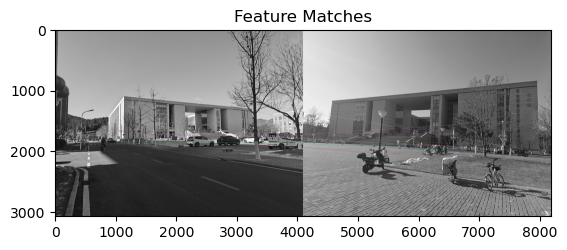

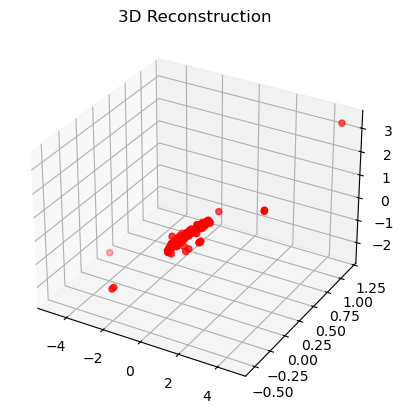

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt


img1 = cv2.imread('./data/1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('./data/2.jpg', cv2.IMREAD_GRAYSCALE)

# 检测特征点并匹配
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_matches)
plt.title('Feature Matches')
plt.show()

# 提取匹配点
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# 计算基础矩阵
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)

# 计算本质矩阵

fx, fy = 1000, 1000  
cx, cy = img1.shape[1] // 2, img1.shape[0] // 2

K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])  
E = K.T @ F @ K

# 从本质矩阵恢复相机姿态
_, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K)

# 三角化重建
P1 = np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = np.hstack((R, t))
P1 = K @ P1
P2 = K @ P2
points_4d = cv2.triangulatePoints(P1, P2, pts1, pts2)
points_3d = points_4d[:3] / points_4d[3]

# 绘制三维点
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_3d[0], points_3d[1], points_3d[2], c='r', marker='o')
plt.title('3D Reconstruction')
plt.show()

正在读取: ./data/phtos\IMG20251204200441.jpg


d:\Users\Grimm\anaconda3\envs\cvlab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26827 (\N{CJK UNIFIED IDEOGRAPH-68CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\cvlab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\cvlab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\cvlab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\cvlab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK U

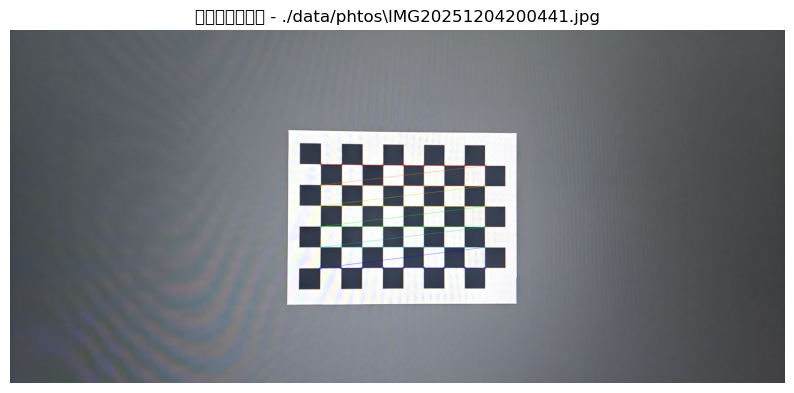

✓ ./data/phtos\IMG20251204200441.jpg: 成功检测到角点
正在读取: ./data/phtos\IMG20251204200444.jpg


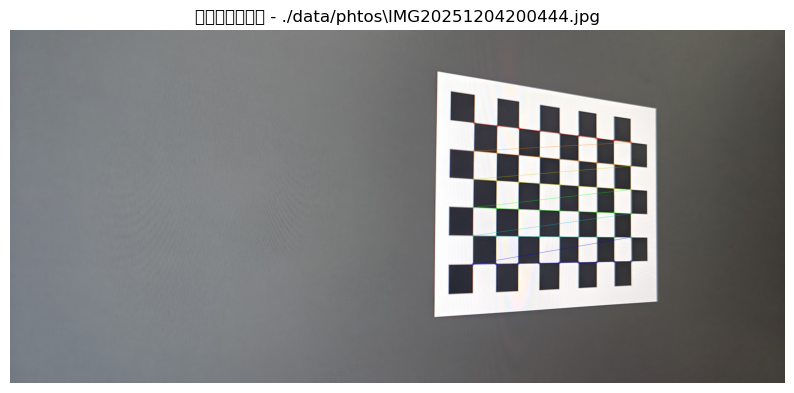

✓ ./data/phtos\IMG20251204200444.jpg: 成功检测到角点
正在读取: ./data/phtos\IMG20251204200447.jpg


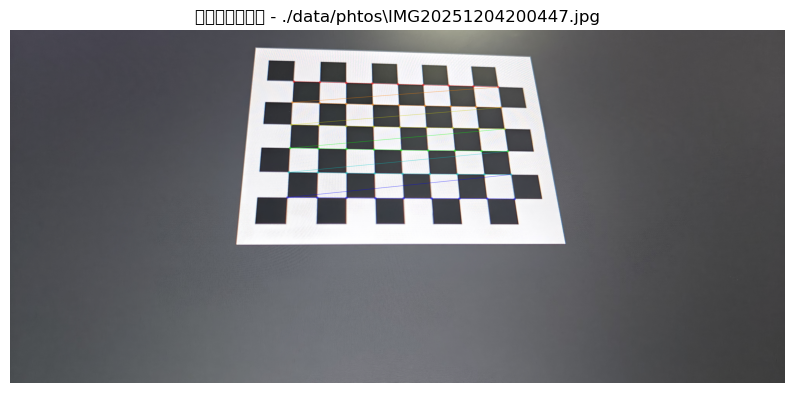

✓ ./data/phtos\IMG20251204200447.jpg: 成功检测到角点

1. OPENCV完整模型标定
图像数目: 3
焦距 fx: 2952.95
焦距 fy: 2953.74
主点 cx: 2076.28
主点 cy: 938.12
径向畸变: k1=-2.698941, k2=143.955050
切向畸变: p1=-0.000801, p2=-0.000703
三维点数: 162
误差中值: 0.0601
误差均值: 0.0553

2. 普通手机参数模型标定（焦距、主点、径向畸变和切向畸变参数）
图像数目: 3
焦距 fx: 2874.91
焦距 fy: 2872.75
主点 cx: 2065.82
主点 cy: 958.12
径向畸变: k1=0.112926, k2=-0.504302
切向畸变: p1=-0.000697, p2=-0.001022
三维点数: 162
误差中值: 0.0966
误差均值: 0.0915

3. 鱼眼相机模型标定
图像数目: 3
焦距 fx: 2943.50
焦距 fy: 2944.39
主点 cx: 2079.42
主点 cy: 944.86
径向畸变: k1=0.783610, k2=-5.809008
切向畸变: k3=27.119322, k4=-38.342420
三维点数: 162
误差中值: 0.0617
误差均值: 0.0559


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import glob


file = './data/phtos'

# 棋盘格的角点数目（内角点，行和列）
chessboard_size = (9, 6)

# 每个棋盘格格子的实际大小（单位：毫米）
square_size = 15

# 准备棋盘格的3D点坐标
objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)
objp *= square_size

# 用于存储所有图片的3D点和2D点
objpoints = []  # 3D点
imgpoints = []  # 2D点

# 选择3张示例图像
images = glob.glob(os.path.join(file, '*.jpg'))

# 逐个处理图像，检测棋盘格角点
for filename in images:
    img_path = filename
    print(f"正在读取: {img_path}")
    img = cv2.imread(img_path)
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 寻找棋盘格角点
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    
    if ret:
        # 精确化角点位置
        corners_refined = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        )
        
        objpoints.append(objp)
        imgpoints.append(corners_refined)
        
        # 绘制角点
        img_corners = cv2.drawChessboardCorners(img.copy(), chessboard_size, corners_refined, ret)
        
        # 显示结果
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
        plt.title(f'棋盘格检测结果 - {filename}')
        plt.axis('off')
        plt.show()
        
        print(f"✓ {filename}: 成功检测到角点")
    else:
        print(f"✗ {filename}: 未检测到棋盘格角点")

# 获取图像尺寸
image_size = gray.shape[::-1]

# 定义函数计算重投影误差
def calculate_reprojection_error(objpoints, imgpoints, rvecs, tvecs, mtx, dist, fisheye_flag=False):
    total_error = 0
    all_errors = []
    for i in range(len(objpoints)):
        if not fisheye_flag:
            imgpoints_proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        else:
            imgpoints_proj, _ = cv2.fisheye.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        error = cv2.norm(imgpoints[i], imgpoints_proj, cv2.NORM_L2) / len(imgpoints_proj)
        total_error += error
        all_errors.append(error)
    mean_error = total_error / len(objpoints)
    median_error = np.median(all_errors)
    return mean_error, median_error

print("\n" + "="*60)
print("1. OPENCV完整模型标定")
print("="*60)
ret, mtx_opencv, dist_opencv, rvecs_opencv, tvecs_opencv = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None,
    flags=cv2.CALIB_RATIONAL_MODEL
)
mean_error, median_error = calculate_reprojection_error(objpoints, imgpoints, rvecs_opencv, tvecs_opencv, mtx_opencv, dist_opencv)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {mtx_opencv[0, 0]:.2f}")
print(f"焦距 fy: {mtx_opencv[1, 1]:.2f}")
print(f"主点 cx: {mtx_opencv[0, 2]:.2f}")
print(f"主点 cy: {mtx_opencv[1, 2]:.2f}")
print(f"径向畸变: k1={dist_opencv[0][0]:.6f}, k2={dist_opencv[0][1]:.6f}")
print(f"切向畸变: p1={dist_opencv[0][2]:.6f}, p2={dist_opencv[0][3]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")

print("\n" + "="*60)
print("2. 普通手机参数模型标定（焦距、主点、径向畸变和切向畸变参数）")
print("="*60)
ret, mtx_phone, dist_phone, rvecs_phone, tvecs_phone = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None,
    flags=cv2.CALIB_FIX_K3
)
mean_error, median_error = calculate_reprojection_error(objpoints, imgpoints, rvecs_phone, tvecs_phone, mtx_phone, dist_phone)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {mtx_phone[0, 0]:.2f}")
print(f"焦距 fy: {mtx_phone[1, 1]:.2f}")
print(f"主点 cx: {mtx_phone[0, 2]:.2f}")
print(f"主点 cy: {mtx_phone[1, 2]:.2f}")
print(f"径向畸变: k1={dist_phone[0][0]:.6f}, k2={dist_phone[0][1]:.6f}")
print(f"切向畸变: p1={dist_phone[0][2]:.6f}, p2={dist_phone[0][3]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")

print("\n" + "="*60)
print("3. 鱼眼相机模型标定")
print("="*60)
objpoints_fisheye = [np.array(objp, dtype=np.float32).reshape(-1, 1, 3) for objp in objpoints]
imgpoints_fisheye = [np.array(imgp, dtype=np.float32).reshape(-1, 1, 2) for imgp in imgpoints]
K = np.zeros((3, 3))
D = np.zeros((4, 1))
flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW
rms, K, D, rvecs_fisheye, tvecs_fisheye = cv2.fisheye.calibrate(
    objpoints_fisheye, imgpoints_fisheye, image_size, K, D, flags=flags,
    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
)
mean_error, median_error = calculate_reprojection_error(objpoints_fisheye, imgpoints_fisheye, rvecs_fisheye, tvecs_fisheye, K, D, True)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {K[0, 0]:.2f}")
print(f"焦距 fy: {K[1, 1]:.2f}")
print(f"主点 cx: {K[0, 2]:.2f}")
print(f"主点 cy: {K[1, 2]:.2f}")
print(f"径向畸变: k1={D[0][0]:.6f}, k2={D[1][0]:.6f}")
print(f"切向畸变: k3={D[2][0]:.6f}, k4={D[3][0]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")